#  Notebook 06: Baseline Modeling Strategy

##  Σύνοψη
Σε αυτό το στάδιο αναπτύσσουμε τα μοντέλα αναφοράς (Baselines). Αυτά τα μοντέλα αποτελούν το μέτρο σύγκρισης (benchmark) για τις πιο σύνθετες αρχιτεκτονικές που θα ακολουθήσουν.

##  Μοντέλα
1. **Persistence Model (Naïve Forecast):** Η παραδοχή ότι η ισχύς τη στιγμή $t+1$ θα είναι ίδια με τη στιγμή $t$.
2. **Linear Regression:** Ένα απλό γραμμικό μοντέλο που συνδέει τις καιρικές παραμέτρους και τα lag features με την παραγόμενη ισχύ.

In [2]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Σύνδεση με το config για να ξέρει το notebook πού είναι τα δεδομένα
sys.path.append(str(Path.cwd().parent))
from src.config import DATA_PROCESSED, TARGET_COLUMN

# Φορτώνουμε μόνο το Test Set για το Persistence (είναι αρκετό για την αρχή)
test_df = pd.read_csv(DATA_PROCESSED / "test_final.csv")

print(f"Loaded {len(test_df):,} samples for baseline testing.")

Loaded 82,797 samples for baseline testing.


In [5]:
# 1. Δημιουργία του Persistence (Naïve) Forecast
# Χρησιμοποιούμε το test_df 
test_df['Persistence_Pred'] = test_df[TARGET_COLUMN].shift(1)

# Δημιουργούμε το persistence_df αφαιρώντας το NaN (την πρώτη σειρά)
persistence_df = test_df.dropna(subset=['Persistence_Pred']).copy()

# 2. Προετοιμασία Δεδομένων για Linear Regression
# Φορτώνουμε το Train Set
train_df = pd.read_csv(DATA_PROCESSED / "train_final.csv")

# Επιλέγουμε ΜΟΝΟ αριθμητικές στήλες για να αποφύγουμε το ValueError με τα strings (timestamps)
X_train = train_df.select_dtypes(include=[np.number]).drop(columns=[TARGET_COLUMN], errors='ignore')
y_train = train_df[TARGET_COLUMN]

# Χρησιμοποιούμε τις ίδιες στήλες για το Test Set από το persistence_df
X_test = persistence_df.select_dtypes(include=[np.number]).drop(columns=[TARGET_COLUMN, 'Persistence_Pred'], errors='ignore')
y_test = persistence_df[TARGET_COLUMN]

# 3. Εκπαίδευση & Πρόβλεψη
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)

print(f"Επιτυχία!")
print(f"Features που χρησιμοποιήθηκαν: {list(X_train.columns)}")
print(f"Δείγματα Test: {len(y_test)}")

Επιτυχία!
Features που χρησιμοποιήθηκαν: ['nwp_fcst_horiz_hours', 'T_HAG_2_M', 'RELHUM_HAG_2_M', 'PS_SFC_0_M', 'U_GVL_58_HL', 'V_GVL_58_HL', 'U_GVL_60_HL', 'V_GVL_60_HL', 'ASWDIFDS_SFC_0_M', 'ASWDIRS_SFC_0_M', 'U_GVL_58_HL_m1', 'V_GVL_58_HL_m1', 'U_GVL_60_HL_m1', 'V_GVL_60_HL_m1', 'U_GVL_58_HL_p1', 'V_GVL_58_HL_p1', 'U_GVL_60_HL_p1', 'V_GVL_60_HL_p1', 'ws_ref', 'Wind_Speed_100m_ms', 'test_flag', 'Baseline_Prediction', 'park_id', 'hour', 'month', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'Power_Output_Normalized_lag_1', 'Power_Output_Normalized_lag_3', 'Power_Output_Normalized_lag_6', 'Wind_Speed_100m_ms_lag_1', 'Wind_Speed_100m_ms_lag_3', 'Wind_Speed_100m_ms_lag_6', 'power_rolling_mean_6h', 'power_rolling_std_6h', 'lat', 'lon']
Δείγματα Test: 82796


In [6]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def get_metrics(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {'Model': model_name, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

# Υπολογισμός για Persistence
metrics_p = get_metrics(y_test, persistence_df['Persistence_Pred'], "Persistence")

# Υπολογισμός για Linear Regression
metrics_lr = get_metrics(y_test, lr_preds, "Linear Regression")

# Δημιουργία Συγκριτικού Πίνακα
results_df = pd.DataFrame([metrics_p, metrics_lr])
print(results_df)

               Model       MAE      RMSE        R2
0        Persistence  0.013840  0.019180 -0.796765
1  Linear Regression  0.008278  0.010841  0.425943


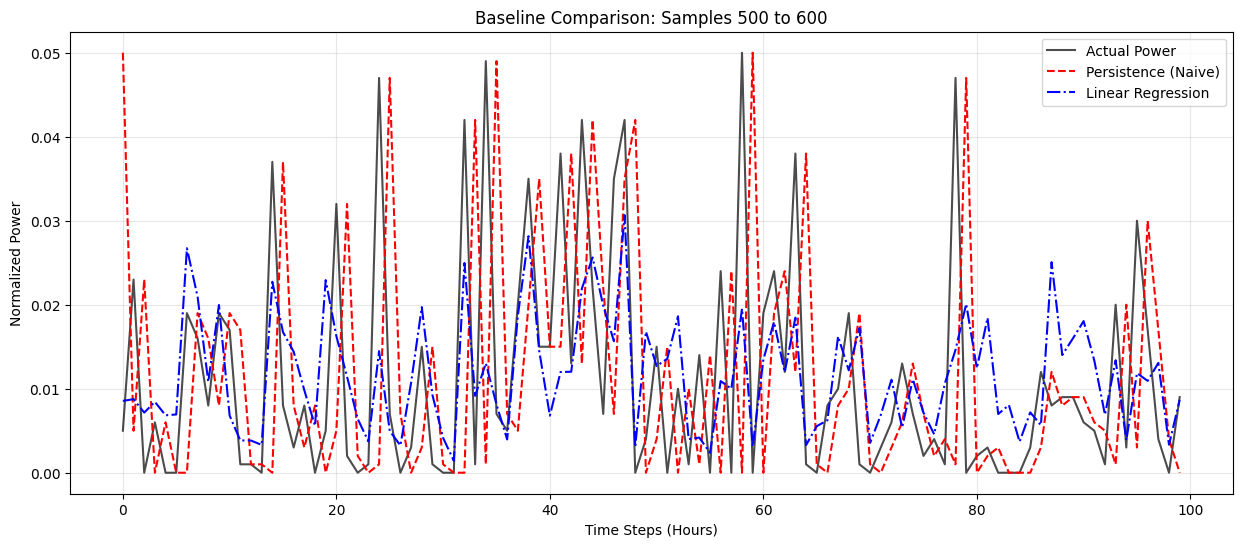

In [7]:
import matplotlib.pyplot as plt

# Επιλογή ενός παραθύρου 100 ωρών για καθαρή εικόνα
start, end = 500, 600 

plt.figure(figsize=(15, 6))
plt.plot(y_test.values[start:end], label='Actual Power', color='black', linewidth=1.5, alpha=0.7)
plt.plot(persistence_df['Persistence_Pred'].values[start:end], label='Persistence (Naive)', color='red', linestyle='--')
plt.plot(lr_preds[start:end], label='Linear Regression', color='blue', linestyle='-.')

plt.title(f"Baseline Comparison: Samples {start} to {end}")
plt.ylabel("Normalized Power")
plt.xlabel("Time Steps (Hours)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [8]:
# Αποθήκευση των αποτελεσμάτων για μελλοντική σύγκριση
results_path = DATA_PROCESSED / "baseline_metrics.csv"
results_df.to_csv(results_path, index=False)
print(f"Τα metrics αποθηκεύτηκαν στο: {results_path}")

Τα metrics αποθηκεύτηκαν στο: C:\Users\diony\Desktop\WindPower_DigitalTwin\data\processed\baseline_metrics.csv
